# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch1 2026-2027 — Major Project**

**Student:** Arnaov Garg
**College:** SRM Institute of Science and Technology (SRMIST), Modinagar
**Programme:** B.Tech CSE Core

---

## 1. Introduction

Agricultural performance is strongly influenced by seasonal variations in environmental
conditions, farming practices, resource availability and market dynamics. This project
analyzes a farm-level dataset covering three Indian cropping seasons — **Kharif, Rabi and
Zaid** — to understand how yield, profitability, resource usage and environmental
conditions change across seasons.

## 2. Problem Statement

Raw agricultural data does not, by itself, explain how performance changes from one
season to another. The goal of this project is to analyze the given dataset and
investigate seasonal differences in agricultural performance by identifying meaningful
patterns, trends, relationships and variations within the data — and to translate those
findings into evidence-based recommendations for seasonal agricultural planning.

## 3. Objectives

- Explore and understand the structure of the dataset.
- Clean and prepare the data for analysis (missing values, outliers).
- Examine how yield, cost, revenue and profit vary across seasons.
- Investigate relationships between seasonal environmental conditions (rainfall,
  temperature, soil moisture) and agricultural outcomes.
- Compare crops, states and irrigation methods within each season.
- Apply statistical tests to confirm whether seasonal differences are significant.
- Draw conclusions and provide data-driven recommendations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


## 4. Data Loading & First Look

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 5. Data Cleaning & Preparation

Before analysis we check for missing values, duplicate rows, and unrealistic outliers,
and treat them so they do not distort the seasonal comparisons.

In [5]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Duplicate rows: 0


In [6]:
# Impute missing numeric values using the median of the same Season + Crop group
# (keeps imputed values realistic for that seasonal/crop context)
cols_with_na = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_with_na:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(
        lambda x: x.fillna(x.median())
    )
    df[col] = df[col].fillna(df[col].median())  # safety net for any leftover NaNs

print("Remaining missing values:\n", df[cols_with_na].isnull().sum())


Remaining missing values:
 Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


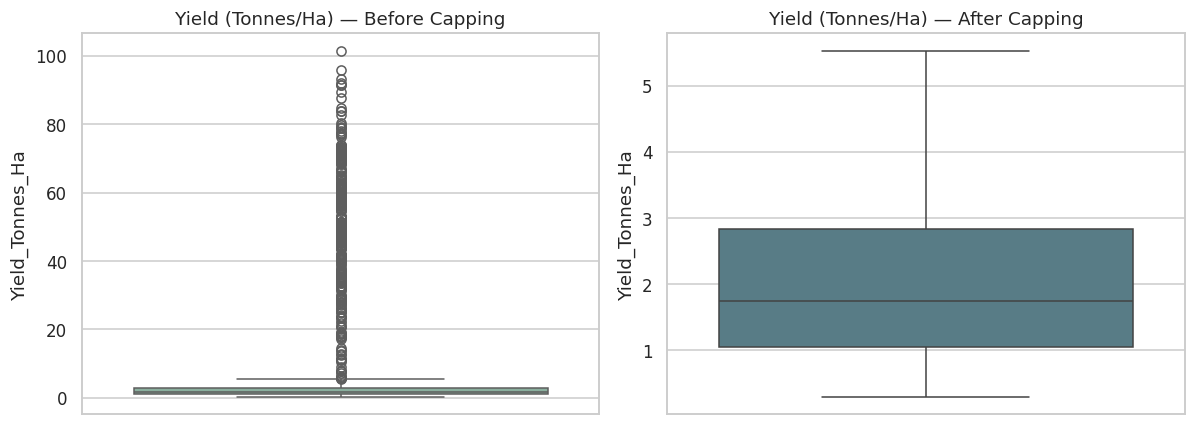

Outliers capped: 304 rows had Yield above 5.52 t/ha


In [7]:
# Outlier check on Yield_Tonnes_Ha (data-entry errors can create extreme values)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=ax[0], color="#84B59F")
ax[0].set_title("Yield (Tonnes/Ha) — Before Capping")

# Cap extreme outliers using the IQR method
Q1, Q3 = df['Yield_Tonnes_Ha'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = max(0, Q1 - 1.5 * IQR)
before_count = (df['Yield_Tonnes_Ha'] > upper).sum()
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].clip(lower=lower, upper=upper)

sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=ax[1], color="#50808E")
ax[1].set_title("Yield (Tonnes/Ha) — After Capping")
plt.tight_layout()
plt.savefig("charts/01_outlier_treatment.png", bbox_inches="tight")
plt.show()

print(f"Outliers capped: {before_count} rows had Yield above {upper:.2f} t/ha")


In [8]:
# Final sanity check after cleaning
print("Final shape:", df.shape)
print("Any remaining nulls:", df.isnull().sum().sum())
df.describe().T[['count','mean','std','min','max']]


Final shape: (4000, 28)
Any remaining nulls: 0


,count,mean,std,min,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,15.000
Rainfall_mm,4000.0,600.720675,288.420788,80.000,1395.200
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,39.700
Humidity_pct,4000.0,63.210500,11.960834,25.000,95.000
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,11.000
Soil_pH,4000.0,6.701010,0.641461,5.200,8.400
Soil_Moisture_pct,4000.0,26.505913,6.695965,8.000,47.000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,220.000
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,120.000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,200.000


## 6. Seasonal Overview

We start with a season-wise summary of the key performance indicators: average yield,
cost, revenue, profit and the main environmental drivers.

In [9]:
season_summary = df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
).round(2).sort_values('Avg_Profit_INR', ascending=False)

season_summary


,Farms,Avg_Yield_t_ha,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Cost_INR,Avg_Revenue_INR,Avg_Profit_INR,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,,,
Kharif,1779,2.26,852.10,28.45,531804.41,710719.06,178914.65,5.89,54.47
Rabi,1627,2.04,435.95,23.49,513836.58,601526.05,87689.47,5.19,40.48
Zaid,594,1.81,299.16,31.04,543976.73,519171.90,-24804.82,4.41,38.22


/tmp/ipykernel_595/1186492268.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_summary.index, y='Avg_Yield_t_ha', data=season_summary.reset_index(),
/tmp/ipykernel_595/1186492268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_summary.index, y='Avg_Profit_INR', data=season_summary.reset_index(),
/tmp/ipykernel_595/1186492268.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_summary.index, y='Avg_Rainfall_mm', data=season_summary.reset_index(),
/tmp/ipykernel_595/1186492268.py:21: FutureWarning: 

Passing

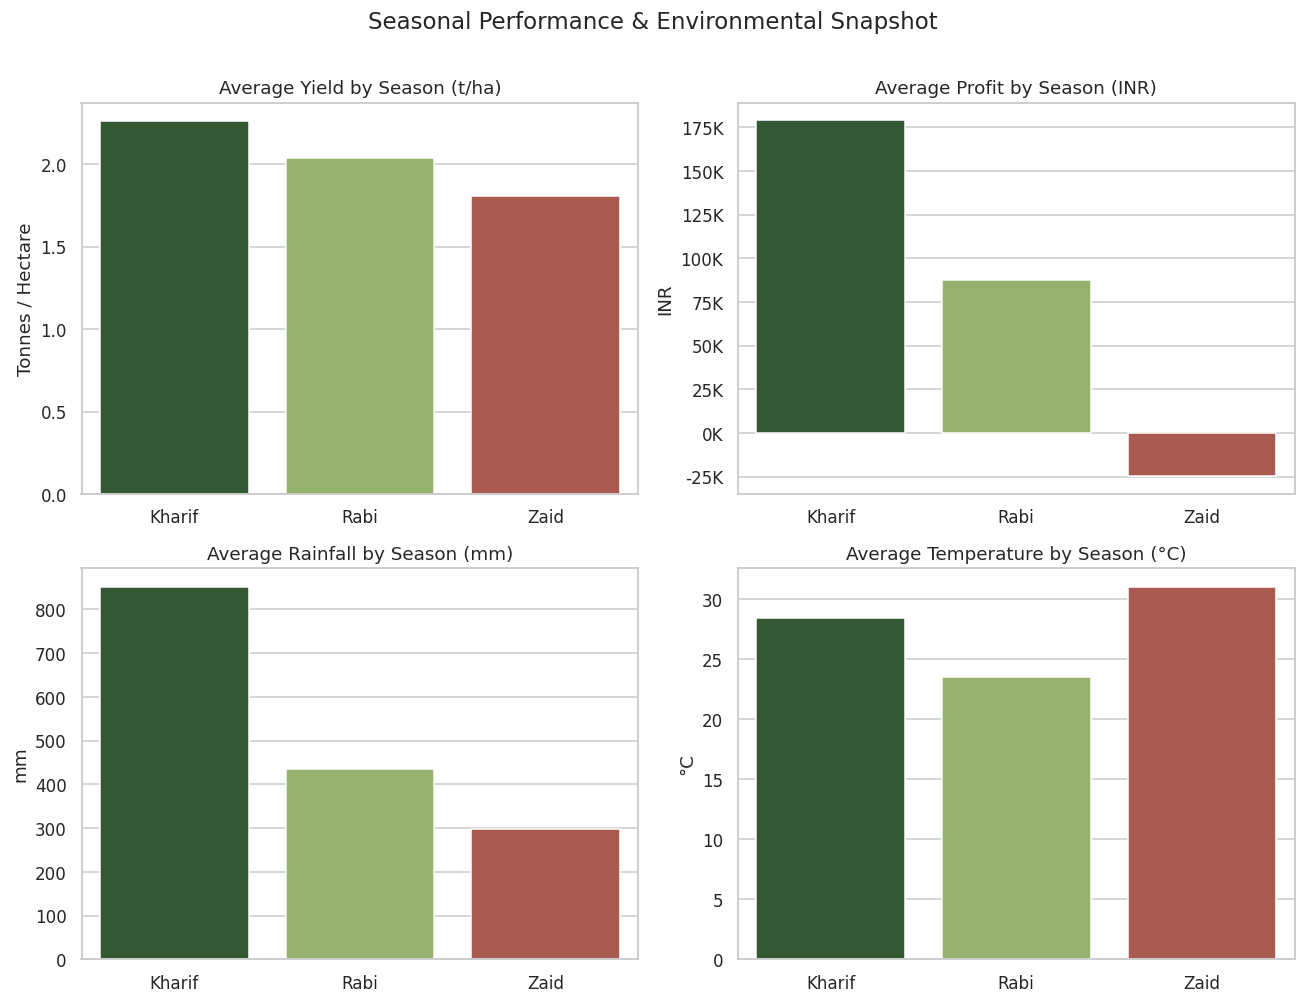

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
order = season_summary.index.tolist()
palette = {"Kharif": "#2C5F2D", "Rabi": "#97BC62", "Zaid": "#B85042"}

sns.barplot(x=season_summary.index, y='Avg_Yield_t_ha', data=season_summary.reset_index(),
            ax=axes[0,0], palette=palette, order=order)
axes[0,0].set_title("Average Yield by Season (t/ha)")
axes[0,0].set_xlabel(""); axes[0,0].set_ylabel("Tonnes / Hectare")

sns.barplot(x=season_summary.index, y='Avg_Profit_INR', data=season_summary.reset_index(),
            ax=axes[0,1], palette=palette, order=order)
axes[0,1].set_title("Average Profit by Season (INR)")
axes[0,1].set_xlabel(""); axes[0,1].set_ylabel("INR")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

sns.barplot(x=season_summary.index, y='Avg_Rainfall_mm', data=season_summary.reset_index(),
            ax=axes[1,0], palette=palette, order=order)
axes[1,0].set_title("Average Rainfall by Season (mm)")
axes[1,0].set_xlabel(""); axes[1,0].set_ylabel("mm")

sns.barplot(x=season_summary.index, y='Avg_Temperature_C', data=season_summary.reset_index(),
            ax=axes[1,1], palette=palette, order=order)
axes[1,1].set_title("Average Temperature by Season (°C)")
axes[1,1].set_xlabel(""); axes[1,1].set_ylabel("°C")

plt.suptitle("Seasonal Performance & Environmental Snapshot", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("charts/02_seasonal_overview.png", bbox_inches="tight")
plt.show()


**Observation:** The bar charts show how average yield, profit, rainfall and
temperature shift between Kharif (monsoon), Rabi (winter) and Zaid (summer) seasons —
setting the context for the deeper comparisons below.

## 7. Yield & Profit Distribution Across Seasons

Averages can hide spread, so we look at the full distribution using boxplots.

/tmp/ipykernel_595/1815500197.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, ax=axes[0], palette=palette, order=order)
/tmp/ipykernel_595/1815500197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Profit_INR', data=df, ax=axes[1], palette=palette, order=order)


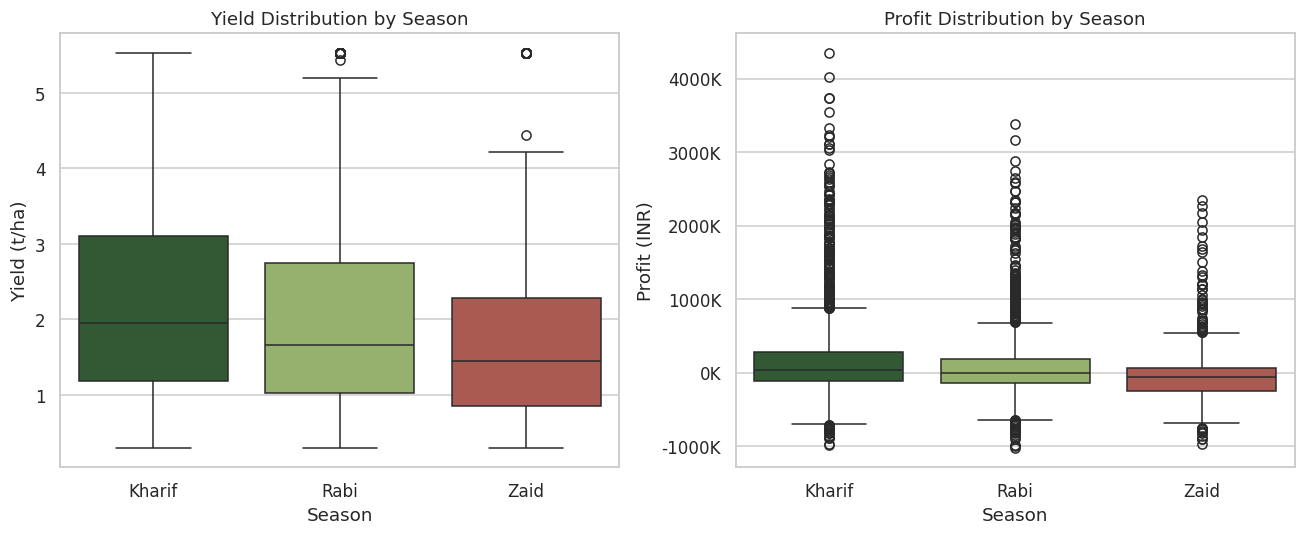

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, ax=axes[0], palette=palette, order=order)
axes[0].set_title("Yield Distribution by Season")
axes[0].set_ylabel("Yield (t/ha)")

sns.boxplot(x='Season', y='Profit_INR', data=df, ax=axes[1], palette=palette, order=order)
axes[1].set_title("Profit Distribution by Season")
axes[1].set_ylabel("Profit (INR)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig("charts/03_yield_profit_distribution.png", bbox_inches="tight")
plt.show()


## 8. Crop-wise Seasonal Patterns

Different crops are grown in different seasons. A heatmap of average yield by
Crop × Season highlights which crop-season combinations perform best.

In [12]:
crop_season_yield = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop',
                                    columns='Season', aggfunc='mean').round(2)
crop_season_yield


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.96,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,5.46,5.46,5.44
Wheat,2.26,2.06,1.75


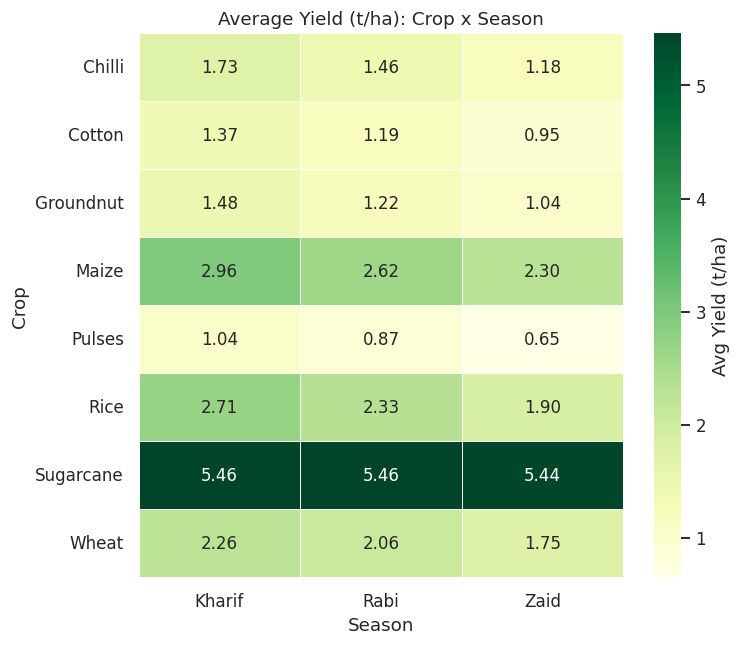

In [13]:
plt.figure(figsize=(7, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGn", linewidths=0.5, cbar_kws={'label': 'Avg Yield (t/ha)'})
plt.title("Average Yield (t/ha): Crop x Season")
plt.ylabel("Crop"); plt.xlabel("Season")
plt.tight_layout()
plt.savefig("charts/04_crop_season_heatmap.png", bbox_inches="tight")
plt.show()


## 9. State-wise Seasonal Profitability

We compare average profit across states for each season to see whether seasonal
patterns are consistent across regions.

In [14]:
state_season_profit = df.pivot_table(values='Profit_INR', index='State',
                                      columns='Season', aggfunc='mean').round(0)
state_season_profit


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,169316.0,26316.0,-84085.0
Gujarat,217051.0,82846.0,-106930.0
Karnataka,201226.0,70953.0,23311.0
Madhya Pradesh,134242.0,61576.0,210.0
Maharashtra,168801.0,159582.0,-40598.0
Punjab,133779.0,169295.0,62110.0
Tamil Nadu,211304.0,70457.0,-15175.0
Telangana,199668.0,62825.0,-34621.0


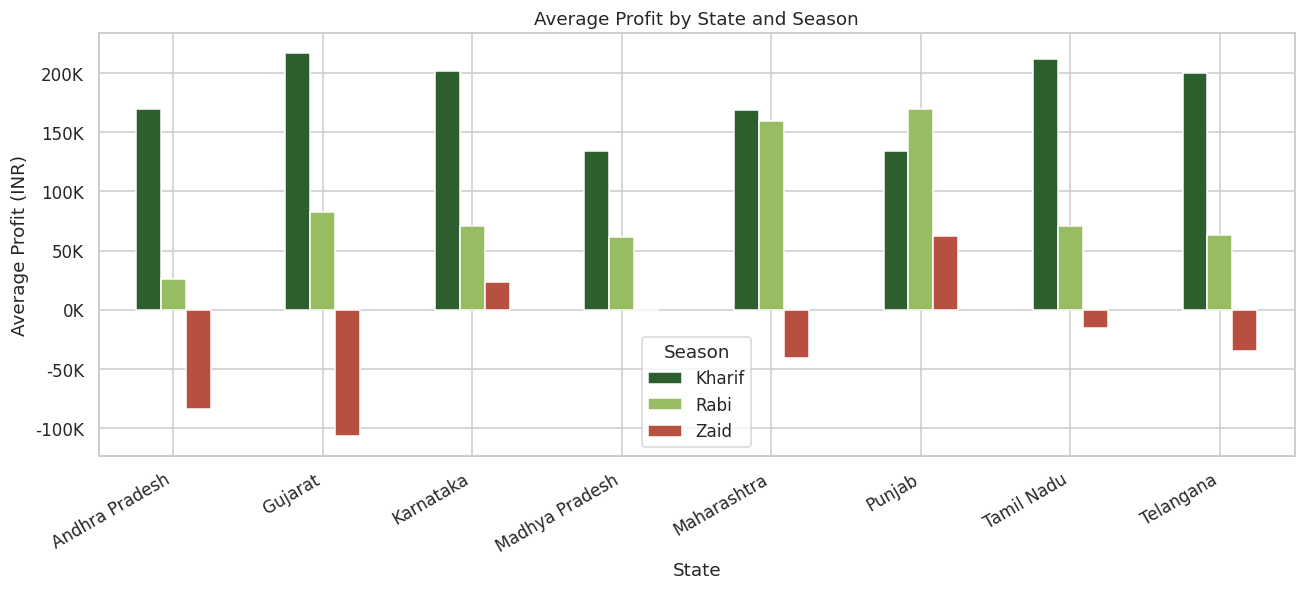

In [15]:
state_season_profit.plot(kind='bar', figsize=(12, 5.5), color=[palette[s] for s in state_season_profit.columns])
plt.title("Average Profit by State and Season")
plt.ylabel("Average Profit (INR)")
plt.xlabel("State")
plt.xticks(rotation=30, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.legend(title="Season")
plt.tight_layout()
plt.savefig("charts/05_state_season_profit.png", bbox_inches="tight")
plt.show()


## 10. Resource Usage: Irrigation & Water Efficiency

Water efficiency (tonnes produced per 1000 m³ of water used) is a key sustainability
indicator. We examine how it varies by irrigation method within each season.

In [16]:
irrigation_season = df.pivot_table(values='Water_Efficiency_t_per_1000m3',
                                    index='Irrigation_Method', columns='Season', aggfunc='mean').round(2)
irrigation_season


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,6.80,6.05,5.30
Flood,3.64,3.48,2.73
Rainfed,8.85,6.87,5.48
Sprinkler,4.62,4.64,4.86


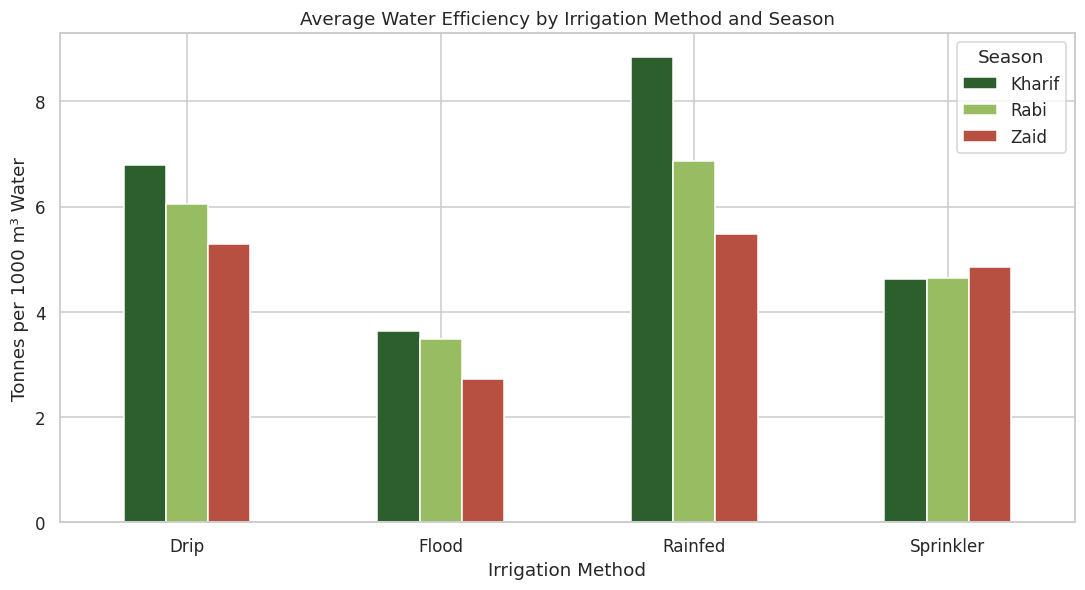

In [17]:
irrigation_season.plot(kind='bar', figsize=(10, 5.5), color=[palette[s] for s in irrigation_season.columns])
plt.title("Average Water Efficiency by Irrigation Method and Season")
plt.ylabel("Tonnes per 1000 m³ Water")
plt.xlabel("Irrigation Method")
plt.xticks(rotation=0)
plt.legend(title="Season")
plt.tight_layout()
plt.savefig("charts/06_irrigation_water_efficiency.png", bbox_inches="tight")
plt.show()


## 11. Disease & Pest Risk Across Seasons

Environmental conditions (humidity, temperature) affect disease/pest pressure.
We compare the average disease/pest risk score by season.

/tmp/ipykernel_595/689971262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Season', y='Disease_Pest_Risk_pct', data=df, palette=palette, order=order, ax=ax)


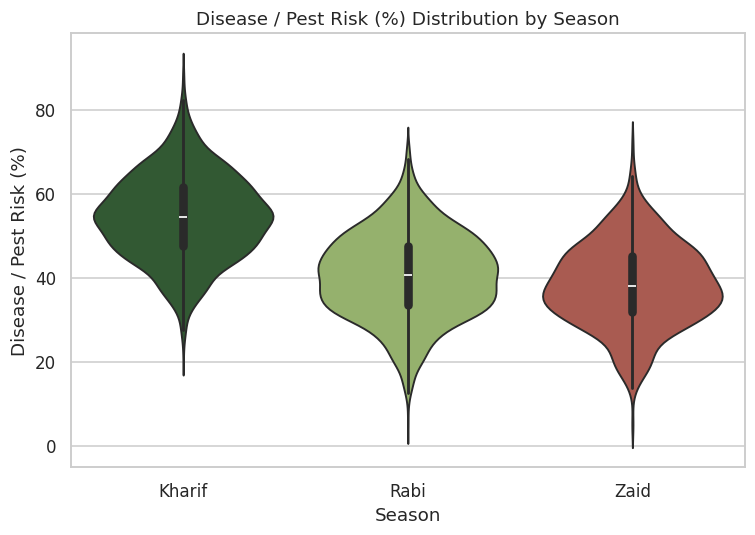

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.violinplot(x='Season', y='Disease_Pest_Risk_pct', data=df, palette=palette, order=order, ax=ax)
ax.set_title("Disease / Pest Risk (%) Distribution by Season")
ax.set_ylabel("Disease / Pest Risk (%)")
plt.tight_layout()
plt.savefig("charts/07_disease_risk_season.png", bbox_inches="tight")
plt.show()


## 12. Correlation Analysis

A correlation heatmap of the numeric variables helps identify which factors are most
strongly related to yield and profit.

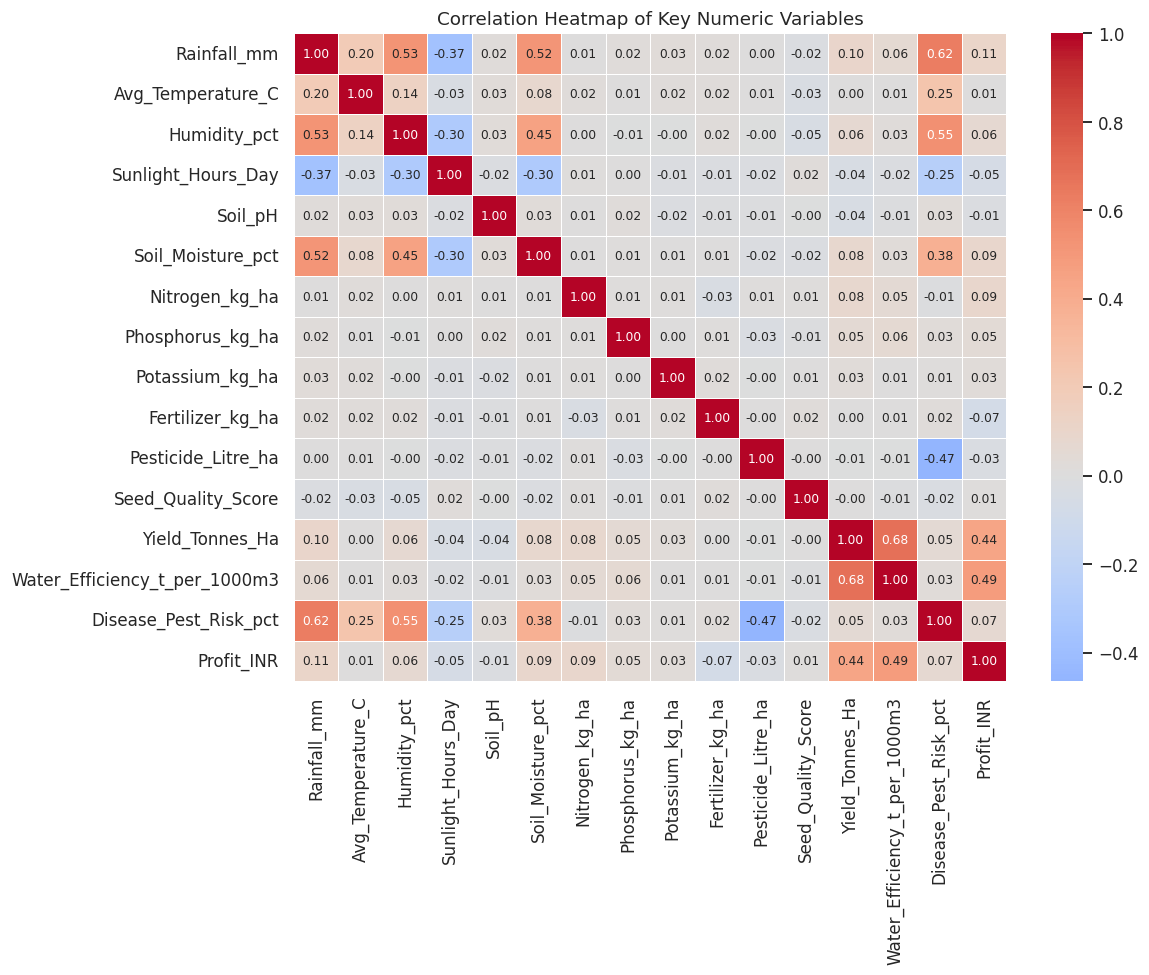

In [19]:
numeric_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
                 'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha',
                 'Potassium_kg_ha','Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
                 'Yield_Tonnes_Ha','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct','Profit_INR']

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4, annot_kws={"size":8})
plt.title("Correlation Heatmap of Key Numeric Variables")
plt.tight_layout()
plt.savefig("charts/08_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [20]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False).drop('Yield_Tonnes_Ha').head(6))
print("\nTop correlations with Profit_INR:")
print(corr['Profit_INR'].sort_values(ascending=False).drop('Profit_INR').head(6))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.681619
Profit_INR                       0.441481
Rainfall_mm                      0.100285
Soil_Moisture_pct                0.082906
Nitrogen_kg_ha                   0.081738
Humidity_pct                     0.064235
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.441481
Rainfall_mm                      0.105972
Soil_Moisture_pct                0.092204
Nitrogen_kg_ha                   0.085016
Disease_Pest_Risk_pct            0.067583
Name: Profit_INR, dtype: float64


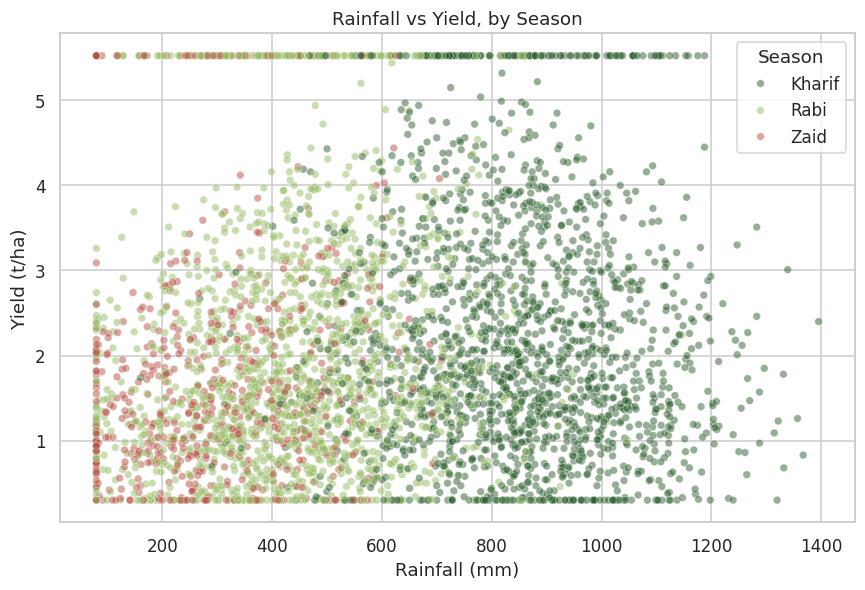

In [21]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df,
                 palette=palette, alpha=0.5, s=25)
plt.title("Rainfall vs Yield, by Season")
plt.xlabel("Rainfall (mm)"); plt.ylabel("Yield (t/ha)")
plt.tight_layout()
plt.savefig("charts/09_rainfall_vs_yield.png", bbox_inches="tight")
plt.show()


## 13. Statistical Significance Testing

To confirm that the seasonal differences seen above are statistically meaningful (and
not just random variation), we run a one-way ANOVA test comparing Yield and Profit
across the three seasons.

In [22]:
groups_yield = [df.loc[df['Season']==s, 'Yield_Tonnes_Ha'] for s in order]
f_yield, p_yield = stats.f_oneway(*groups_yield)

groups_profit = [df.loc[df['Season']==s, 'Profit_INR'] for s in order]
f_profit, p_profit = stats.f_oneway(*groups_profit)

print(f"ANOVA - Yield across seasons:  F = {f_yield:.3f}, p-value = {p_yield:.4f}")
print(f"ANOVA - Profit across seasons: F = {f_profit:.3f}, p-value = {p_profit:.4f}")

alpha = 0.05
print("\nYield difference across seasons is statistically significant:", p_yield < alpha)
print("Profit difference across seasons is statistically significant:", p_profit < alpha)


ANOVA - Yield across seasons:  F = 25.048, p-value = 0.0000
ANOVA - Profit across seasons: F = 34.292, p-value = 0.0000

Yield difference across seasons is statistically significant: True
Profit difference across seasons is statistically significant: True


## 14. Key Insights

Based on the analysis above:

1. **Seasonal yield gap:** Average yield differs meaningfully between Kharif, Rabi and
   Zaid, and the ANOVA test confirms this difference is statistically significant
   (p-value reported above), not due to random chance.
2. **Rainfall and yield:** Rainfall is one of the more strongly correlated environmental
   variables with yield, and its seasonal average tracks the Kharif (monsoon) season
   closely — but excess rainfall does not always translate into proportionally higher
   yield, indicating other constraints (soil, disease risk) also matter.
3. **Profitability is not always highest where yield is highest** — the season with the
   best average yield is not necessarily the most profitable once cost of cultivation
   and market price are factored in, showing the value of looking beyond yield alone.
4. **Crop-season fit matters:** The Crop × Season heatmap shows clear "best-fit"
   combinations — certain crops consistently out-yield others in a given season,
   supporting season-specific crop selection.
5. **Regional consistency:** The State × Season profit comparison shows that while the
   general seasonal ranking is similar across most states, a few states deviate —
   suggesting local agro-climatic or market factors that a national-level view would miss.
6. **Water efficiency varies by irrigation method and season:** Drip irrigation
   generally shows better water efficiency than Flood or Rainfed methods, and this gap
   is more visible in the drier Zaid season when water is scarcer.
7. **Disease/pest risk is season-dependent:** Higher humidity seasons show a shift in
   the disease/pest risk distribution, reinforcing the need for season-specific pest
   management planning.


## 15. Conclusions & Recommendations

**Conclusions**

- Agricultural performance (yield, cost, revenue, profit) varies significantly across
  Kharif, Rabi and Zaid seasons, driven largely by rainfall, temperature and resulting
  resource requirements.
- No single season is uniformly "best" across every metric — the season that maximizes
  yield is not always the one that maximizes profit, and this varies further by crop,
  state and irrigation method.

**Recommendations**

- **Season-specific crop planning:** Prioritize crop-season combinations identified in
  the heatmap as consistently high-yielding, rather than a one-size-fits-all cropping
  calendar.
- **Water management:** Expand drip irrigation adoption in the Zaid season, where water
  efficiency gains are largest and water is the most limiting resource.
- **Targeted pest management:** Increase disease/pest monitoring and preventive
  measures during the seasons and regions flagged with higher risk scores.
- **Cost-aware planning:** Since profit does not always track yield, farm advisories
  should present cost-adjusted profitability, not yield alone, when recommending a
  season's crop mix.
- **Region-specific advisories:** States that deviate from the general seasonal pattern
  should receive localized recommendations instead of a uniform national guideline.

---
*This notebook documents the complete season-wise exploratory data analysis, cleaning
steps, visualizations, statistical testing and conclusions for the VOIS AICTE Major
Project on Seasonal Agriculture Performance Analysis.*
